In [41]:
import sys
from pathlib import Path

current = Path.cwd()

PROJECT_ROOT = None

for path in [current] + list(current.parents):
    if (path / "src").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find project root containing 'src'."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

print("Project root:", PROJECT_ROOT)

import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import roc_auc_score

from src.calibration.calibrator import (
    PlattCalibrator,
)

from src.calibration.metrics import (
    calibration_metrics,
)

from src.utils.device import get_device

print("Imports successful.")

Project root: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service
Imports successful.


In [42]:
DATA_DIR = PROJECT_ROOT / "data"

PROCESSED_DIR = (
    DATA_DIR / "processed"
)

BIOMARKER_DIR = (
    PROCESSED_DIR / "biomarkers"
)

ECG_DIR = (
    PROCESSED_DIR / "ecg"
)

ECHO_DIR = (
    PROCESSED_DIR / "echo"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT / "checkpoints"
)

CALIBRATION_DIR = (
    CHECKPOINT_DIR / "calibration"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "calibration"
)

CALIBRATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = get_device()

print("Device:", DEVICE)
print("Calibration directory:", CALIBRATION_DIR)
print("Results directory:", RESULTS_DIR)

Device: cuda
Calibration directory: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\calibration
Results directory: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\calibration


In [43]:
BIOMARKER_TARGETS = {
    "zheen": [
        "acute_mi",
    ],

    "uci_heart_failure": [
        "hf_mortality",
    ],

    "mi_complications": [
        "post_mi_af",
        "post_mi_svt",
        "post_mi_vt",
        "post_mi_vf",
        "post_mi_av_block",
        "post_mi_pulmonary_edema",
        "post_mi_myocardial_rupture",
        "post_mi_dressler",
        "post_mi_chronic_hf",
        "post_mi_recurrent_mi",
        "post_mi_angina",
    ],

    "framingham": [
        "ten_year_chd_risk",
    ],
}

ECG_DIAGNOSTIC_TARGETS = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP",
]

echo_targets = {
    "lv_dysfunction": 50.0,
    "hfref": 40.0,
}

print("Biomarker targets:")
for source, targets in BIOMARKER_TARGETS.items():
    print(source, "->", targets)

print("\nECG diagnostic targets:")
print(ECG_DIAGNOSTIC_TARGETS)

print("\nEcho derived targets:")
print(echo_targets)

Biomarker targets:
zheen -> ['acute_mi']
uci_heart_failure -> ['hf_mortality']
mi_complications -> ['post_mi_af', 'post_mi_svt', 'post_mi_vt', 'post_mi_vf', 'post_mi_av_block', 'post_mi_pulmonary_edema', 'post_mi_myocardial_rupture', 'post_mi_dressler', 'post_mi_chronic_hf', 'post_mi_recurrent_mi', 'post_mi_angina']
framingham -> ['ten_year_chd_risk']

ECG diagnostic targets:
['NORM', 'MI', 'STTC', 'CD', 'HYP']

Echo derived targets:
{'lv_dysfunction': 50.0, 'hfref': 40.0}


In [44]:
prediction_candidates = [
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "biomarkers"
    / "biomarker_val_predictions.csv",

    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "ecg"
    / "ptbxl_val_predictions.csv",

    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "echo"
    / "echonet_val_predictions.csv",
]

for path in prediction_candidates:
    print(
        path,
        "->",
        path.exists()
    )

d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\biomarkers\biomarker_val_predictions.csv -> True
d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\ecg\ptbxl_val_predictions.csv -> True
d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\metrics\echo\echonet_val_predictions.csv -> True


In [45]:
BIOMARKER_VAL_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "biomarkers"
    / "biomarker_val_predictions.csv"
)

if not BIOMARKER_VAL_PATH.exists():
    raise FileNotFoundError(
        f"Missing validation predictions:\n"
        f"{BIOMARKER_VAL_PATH}\n\n"
        "Do not calibrate using test predictions."
    )

biomarker_val = pd.read_csv(
    BIOMARKER_VAL_PATH
)

print(
    "Biomarker validation shape:",
    biomarker_val.shape
)

display(
    biomarker_val.head()
)

Biomarker validation shape: (3684, 4)


,dataset,target,true,prediction
0,zheen,acute_mi,0.0,0.310431
1,zheen,acute_mi,0.0,0.261154
2,zheen,acute_mi,0.0,0.234210
3,zheen,acute_mi,1.0,0.416536
4,zheen,acute_mi,0.0,0.105503


In [46]:
def calibrate_binary_target(
    dataframe,
    true_column,
    probability_column,
    output_path,
):
    y_true = (
        dataframe[true_column]
        .to_numpy()
    )

    raw_prob = (
        dataframe[probability_column]
        .to_numpy()
    )

    calibrator = PlattCalibrator()

    calibrator.fit(
        raw_prob,
        y_true,
    )

    calibrated_prob = (
        calibrator.predict_proba(
            raw_prob
        )
    )

    metrics = calibration_metrics(
        y_true,
        raw_prob,
        calibrated_prob,
    )

    calibrator.save(
        output_path
    )

    return (
        calibrator,
        calibrated_prob,
        metrics,
    )

In [47]:
acute_mi_calibrator_path = (
    CALIBRATION_DIR
    / "biomarker_acute_mi.pkl"
)

acute_mi_subset = (
    biomarker_val.loc[
        (biomarker_val["dataset"] == "zheen")
        & (biomarker_val["target"] == "acute_mi"),
        ["true", "prediction"],
    ]
    .rename(
        columns={
            "true": "acute_mi_true",
            "prediction": "acute_mi_prob",
        }
    )
    .dropna()
)

acute_mi_calibrator, acute_mi_calibrated, acute_mi_metrics = (
    calibrate_binary_target(
        acute_mi_subset,
        true_column="acute_mi_true",
        probability_column="acute_mi_prob",
        output_path=acute_mi_calibrator_path,
    )
)

print(
    json.dumps(
        acute_mi_metrics,
        indent=2,
    )
)

{
  "raw_brier": 0.16665615785859342,
  "calibrated_brier": 0.15511580602072714,
  "raw_log_loss": 0.5013893769925395,
  "calibrated_log_loss": 0.4632917873546567,
  "raw_ece": 0.12190975448248363,
  "calibrated_ece": 0.06147443021390263
}


In [48]:
biomarker_calibration_results = []

for dataset_name, targets in BIOMARKER_TARGETS.items():

    for target in targets:

        if not {"dataset", "target", "true", "prediction"}.issubset(
            biomarker_val.columns
        ):
            raise ValueError(
                "Biomarker validation predictions must use long schema: "
                "dataset, target, true, prediction."
            )

        subset = biomarker_val[
            (biomarker_val["dataset"] == dataset_name)
            & (biomarker_val["target"] == target)
        ][["true", "prediction"]].dropna()

        if len(subset) == 0:
            print(
                f"Skipping {dataset_name}/{target}: "
                "no valid non-missing rows."
            )
            continue

        subset = subset.rename(
            columns={
                "true": "target_true",
                "prediction": "target_prob",
            }
        )

        output_path = (
            CALIBRATION_DIR
            / "biomarker"
            / f"{dataset_name}_{target}.pkl"
        )

        output_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        _, _, metrics = calibrate_binary_target(
            subset,
            true_column="target_true",
            probability_column="target_prob",
            output_path=output_path,
        )

        biomarker_calibration_results.append({
            "model": "biomarker",
            "dataset": dataset_name,
            "target": target,
            **metrics,
        })

        print(
            f"Calibrated: {dataset_name} / {target}"
        )

Calibrated: zheen / acute_mi
Calibrated: uci_heart_failure / hf_mortality
Calibrated: mi_complications / post_mi_af
Calibrated: mi_complications / post_mi_svt
Calibrated: mi_complications / post_mi_vt
Calibrated: mi_complications / post_mi_vf
Calibrated: mi_complications / post_mi_av_block
Skipping mi_complications/post_mi_pulmonary_edema: no valid non-missing rows.
Calibrated: mi_complications / post_mi_myocardial_rupture
Calibrated: mi_complications / post_mi_dressler
Calibrated: mi_complications / post_mi_chronic_hf
Calibrated: mi_complications / post_mi_recurrent_mi


Calibrated: mi_complications / post_mi_angina
Calibrated: framingham / ten_year_chd_risk


In [49]:
biomarker_calibration_df = pd.DataFrame(
    biomarker_calibration_results
)

display(
    biomarker_calibration_df.round(4)
)

,model,dataset,target,raw_brier,calibrated_brier,raw_log_loss,calibrated_log_loss,raw_ece,calibrated_ece
0,biomarker,zheen,acute_mi,0.1667,0.1551,0.5014,0.4633,0.1219,0.0615
1,biomarker,uci_heart_failure,hf_mortality,0.2285,0.2133,0.6824,0.6169,0.1965,0.1043
2,biomarker,mi_complications,post_mi_af,0.2056,0.0950,0.5963,0.3260,0.3091,0.0109
3,biomarker,mi_complications,post_mi_svt,0.2161,0.0154,0.6218,0.0801,0.4283,0.0000
4,biomarker,mi_complications,post_mi_vt,0.1074,0.0143,0.3562,0.0660,0.2499,0.0035
5,biomarker,mi_complications,post_mi_vf,0.1968,0.0257,0.5794,0.1109,0.3859,0.0026
6,biomarker,mi_complications,post_mi_av_block,0.1341,0.0262,0.4407,0.1131,0.3075,0.0087
7,biomarker,mi_complications,post_mi_myocardial_rupture,0.1661,0.0250,0.5027,0.0995,0.3301,0.0031
8,biomarker,mi_complications,post_mi_dressler,0.1755,0.0606,0.5320,0.2310,0.3107,0.0032
9,biomarker,mi_complications,post_mi_chronic_hf,0.2572,0.1651,0.7075,0.5116,0.3103,0.0428


In [50]:
ECG_VAL_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "ecg"
    / "ptbxl_val_predictions.csv"
)

if ECG_VAL_PATH.exists():
    ecg_val = pd.read_csv(
        ECG_VAL_PATH
    )

    print(
        "PTB-XL validation shape:",
        ecg_val.shape
    )

    display(
        ecg_val.head()
    )

else:
    ecg_val = pd.DataFrame()

    print(
        "PTB-XL validation predictions not found. "
        "Skipping ECG calibration:"
    )
    print(ECG_VAL_PATH)

PTB-XL validation shape: (3266, 11)


,record_path,NORM_true,NORM_prob,MI_true,MI_prob,STTC_true,STTC_prob,CD_true,CD_prob,HYP_true,HYP_prob
0,data\processed\ecg\ptbxl\waveforms\00006_lr.npy,1.0,0.901049,0.0,0.017820,0.0,0.019815,0.0,0.258352,0.0,0.185116
1,data\processed\ecg\ptbxl\waveforms\00015_lr.npy,1.0,0.874096,0.0,0.043456,0.0,0.041508,0.0,0.165785,0.0,0.040685
2,data\processed\ecg\ptbxl\waveforms\00019_lr.npy,1.0,0.993172,0.0,0.007955,0.0,0.000437,0.0,0.011730,0.0,0.008861
3,data\processed\ecg\ptbxl\waveforms\00024_lr.npy,1.0,0.960941,0.0,0.019461,0.0,0.000496,0.0,0.169538,0.0,0.029439
4,data\processed\ecg\ptbxl\waveforms\00037_lr.npy,1.0,0.994116,0.0,0.003340,0.0,0.001342,0.0,0.007626,0.0,0.006697


In [51]:
ecg_calibration_results = []

for target in ECG_DIAGNOSTIC_TARGETS:

    true_column = f"{target}_true"
    probability_column = f"{target}_prob"

    if true_column not in ecg_val.columns:
        print(f"Skipping {target}: {true_column} not found.")
        continue

    if probability_column not in ecg_val.columns:
        print(f"Skipping {target}: {probability_column} not found.")
        continue

    output_path = (
        CALIBRATION_DIR
        / "ecg"
        / f"{target}.pkl"
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    _, _, metrics = calibrate_binary_target(
        ecg_val,
        true_column,
        probability_column,
        output_path,
    )

    ecg_calibration_results.append({
        "model": "ecg",
        "target": target,
        **metrics,
    })

    print(f"Calibrated ECG: {target}")

Calibrated ECG: NORM
Calibrated ECG: MI
Calibrated ECG: STTC
Calibrated ECG: CD
Calibrated ECG: HYP


In [52]:
ecg_calibration_df = pd.DataFrame(
    ecg_calibration_results
)

display(
    ecg_calibration_df.round(4)
)

,model,target,raw_brier,calibrated_brier,raw_log_loss,calibrated_log_loss,raw_ece,calibrated_ece
0,ecg,NORM,0.1055,0.1035,0.3325,0.3246,0.0387,0.0192
1,ecg,MI,0.1465,0.1114,0.4481,0.3528,0.1391,0.0149
2,ecg,STTC,0.1214,0.1023,0.3767,0.3225,0.0906,0.0109
3,ecg,CD,0.1022,0.0853,0.3334,0.2876,0.0919,0.0138
4,ecg,HYP,0.1616,0.0808,0.4803,0.2791,0.2318,0.0150


In [53]:
ECHO_VAL_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "metrics"
    / "echo"
    / "echonet_val_predictions.csv"
)

if not ECHO_VAL_PATH.exists():
    raise FileNotFoundError(
        f"Missing EchoNet validation predictions:\n"
        f"{ECHO_VAL_PATH}"
    )

echo_val = pd.read_csv(
    ECHO_VAL_PATH
)

print(
    "EchoNet validation shape:",
    echo_val.shape
)

display(
    echo_val.head()
)

EchoNet validation shape: (204, 4)


,video_path,true_EF,predicted_EF,absolute_error
0,D:\Programming\VS Code\Projects\CardioFusion-X...,78.498405,61.243904,17.254501
1,D:\Programming\VS Code\Projects\CardioFusion-X...,24.887741,36.597060,11.709320
2,D:\Programming\VS Code\Projects\CardioFusion-X...,69.201744,56.182250,13.019493
3,D:\Programming\VS Code\Projects\CardioFusion-X...,62.365050,48.531550,13.833500
4,D:\Programming\VS Code\Projects\CardioFusion-X...,58.857155,53.492065,5.365089


In [54]:
def ef_to_raw_probability(
    predicted_ef,
    threshold,
    scale=5.0,
):
    predicted_ef = np.asarray(
        predicted_ef,
        dtype=np.float64,
    )

    # Lower EF -> higher probability.
    score = (
        threshold
        - predicted_ef
    ) / scale

    return 1.0 / (
        1.0 + np.exp(-score)
    )

In [55]:
echo_val["lv_dysfunction_true"] = (
    echo_val["true_EF"] < 50
).astype(int)

echo_val["lv_dysfunction_raw"] = (
    ef_to_raw_probability(
        echo_val["predicted_EF"],
        threshold=50.0,
    )
)

echo_val["hfref_true"] = (
    echo_val["true_EF"] < 40
).astype(int)

echo_val["hfref_raw"] = (
    ef_to_raw_probability(
        echo_val["predicted_EF"],
        threshold=40.0,
    )
)

display(
    echo_val[
        [
            "true_EF",
            "predicted_EF",
            "lv_dysfunction_true",
            "lv_dysfunction_raw",
            "hfref_true",
            "hfref_raw",
        ]
    ].head()
)

,true_EF,predicted_EF,lv_dysfunction_true,lv_dysfunction_raw,hfref_true,hfref_raw
0,78.498405,61.243904,0,0.095455,0,0.014081
1,24.887741,36.597060,1,0.935871,1,0.663870
2,69.201744,56.182250,0,0.225055,0,0.037817
3,62.365050,48.531550,0,0.572899,0,0.153643
4,58.857155,53.492065,0,0.332164,0,0.063067


In [56]:
echo_calibration_results = []

for target, threshold in echo_targets.items():

    true_column = (
        f"{target}_true"
    )

    raw_column = (
        f"{target}_raw"
    )

    output_path = (
        CALIBRATION_DIR
        / "echo"
        / f"{target}.pkl"
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    _, calibrated_prob, metrics = (
        calibrate_binary_target(
            echo_val,
            true_column=true_column,
            probability_column=raw_column,
            output_path=output_path,
        )
    )

    echo_calibration_results.append({
        "model": "echo",
        "target": target,
        "ef_threshold": threshold,
        **metrics,
    })

    print(
        f"Calibrated Echo: "
        f"{target} "
        f"(EF < {threshold:.0f}%)"
    )

Calibrated Echo: lv_dysfunction (EF < 50%)
Calibrated Echo: hfref (EF < 40%)


In [57]:
echo_calibration_df = pd.DataFrame(
    echo_calibration_results
)

display(
    echo_calibration_df.round(4)
)

,model,target,ef_threshold,raw_brier,calibrated_brier,raw_log_loss,calibrated_log_loss,raw_ece,calibrated_ece
0,echo,lv_dysfunction,50.0,0.1302,0.0959,0.4149,0.3126,0.1696,0.0374
1,echo,hfref,40.0,0.0450,0.0417,0.1694,0.1445,0.0578,0.0287


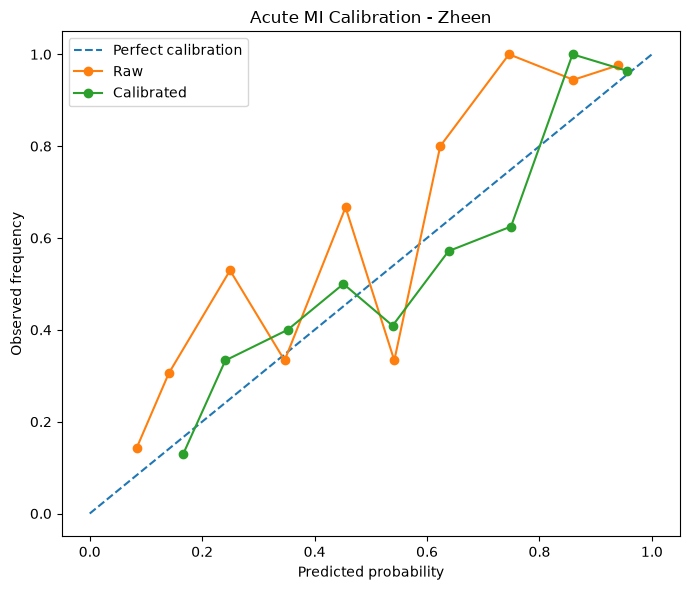

In [58]:
from sklearn.calibration import calibration_curve

required_columns = {
    "dataset",
    "target",
    "true",
    "prediction",
}

missing_columns = required_columns.difference(
    biomarker_val.columns
)

if missing_columns:
    raise ValueError(
        "Biomarker validation predictions are missing columns: "
        f"{sorted(missing_columns)}"
    )

subset = biomarker_val.loc[
    (biomarker_val["dataset"] == "zheen")
    & (biomarker_val["target"] == "acute_mi"),
    ["true", "prediction"],
].dropna()

if subset.empty:
    raise ValueError(
        "No validation predictions found for zheen/acute_mi."
    )

y_true = subset["true"].to_numpy(dtype=int)
raw_prob = subset["prediction"].to_numpy(dtype=float)

calibrator = PlattCalibrator.load(
    acute_mi_calibrator_path
)

calibrated_prob = calibrator.predict_proba(
    raw_prob
)

raw_fraction, raw_mean = calibration_curve(
    y_true,
    raw_prob,
    n_bins=10,
    strategy="uniform",
)

cal_fraction, cal_mean = calibration_curve(
    y_true,
    calibrated_prob,
    n_bins=10,
    strategy="uniform",
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.plot(
    raw_mean,
    raw_fraction,
    marker="o",
    label="Raw",
)

plt.plot(
    cal_mean,
    cal_fraction,
    marker="o",
    label="Calibrated",
)

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Acute MI Calibration - Zheen")

plt.legend()

plt.tight_layout()
plt.show()

In [59]:
calibration_tables = []

if len(biomarker_calibration_df):
    calibration_tables.append(
        biomarker_calibration_df
    )

if len(ecg_calibration_df):
    calibration_tables.append(
        ecg_calibration_df
    )

if len(echo_calibration_df):
    calibration_tables.append(
        echo_calibration_df
    )

if calibration_tables:

    calibration_results = pd.concat(
        calibration_tables,
        ignore_index=True,
    )

else:

    calibration_results = pd.DataFrame()

display(
    calibration_results.round(4)
)

,model,dataset,target,raw_brier,calibrated_brier,raw_log_loss,calibrated_log_loss,raw_ece,calibrated_ece,ef_threshold
0,biomarker,zheen,acute_mi,0.1667,0.1551,0.5014,0.4633,0.1219,0.0615,NaN
1,biomarker,uci_heart_failure,hf_mortality,0.2285,0.2133,0.6824,0.6169,0.1965,0.1043,NaN
2,biomarker,mi_complications,post_mi_af,0.2056,0.0950,0.5963,0.3260,0.3091,0.0109,NaN
3,biomarker,mi_complications,post_mi_svt,0.2161,0.0154,0.6218,0.0801,0.4283,0.0000,NaN
4,biomarker,mi_complications,post_mi_vt,0.1074,0.0143,0.3562,0.0660,0.2499,0.0035,NaN
5,biomarker,mi_complications,post_mi_vf,0.1968,0.0257,0.5794,0.1109,0.3859,0.0026,NaN
6,biomarker,mi_complications,post_mi_av_block,0.1341,0.0262,0.4407,0.1131,0.3075,0.0087,NaN
7,biomarker,mi_complications,post_mi_myocardial_rupture,0.1661,0.0250,0.5027,0.0995,0.3301,0.0031,NaN
8,biomarker,mi_complications,post_mi_dressler,0.1755,0.0606,0.5320,0.2310,0.3107,0.0032,NaN
9,biomarker,mi_complications,post_mi_chronic_hf,0.2572,0.1651,0.7075,0.5116,0.3103,0.0428,NaN


In [60]:
results_path = (
    RESULTS_DIR
    / "calibration_results.csv"
)

calibration_results.to_csv(
    results_path,
    index=False,
)

print(
    "Saved:",
    results_path
)

Saved: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\calibration\calibration_results.csv


In [61]:
calibration_registry = {
    "method": "platt_scaling",
    "models": {
        "biomarker": {},
        "ecg": {},
        "echo": {},
    },
}

for _, row in calibration_results.iterrows():

    model_name = row["model"]

    target = row["target"]

    if model_name == "biomarker":
        relative_path = (
            f"biomarker/{target}.pkl"
        )

    elif model_name == "ecg":
        relative_path = (
            f"ecg/{target}.pkl"
        )

    elif model_name == "echo":
        relative_path = (
            f"echo/{target}.pkl"
        )

    else:
        continue

    calibration_registry[
        "models"
    ].setdefault(
        model_name,
        {}
    )

    calibration_registry[
        "models"
    ][model_name][target] = {
        "file": relative_path,
        "raw_brier": row.get(
            "raw_brier",
            None
        ),
        "calibrated_brier": row.get(
            "calibrated_brier",
            None
        ),
        "raw_ece": row.get(
            "raw_ece",
            None
        ),
        "calibrated_ece": row.get(
            "calibrated_ece",
            None
        ),
    }

registry_path = (
    CALIBRATION_DIR
    / "calibration_registry.json"
)

with open(
    registry_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        calibration_registry,
        f,
        indent=2,
    )

print(
    "Saved:",
    registry_path
)

Saved: d:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\checkpoints\calibration\calibration_registry.json
